# 1. Project Setup and Data Configuration

### Loading and configuring multiple 2011 and 2021 UK Census datasets covering deprivation, health, economic activity, education, and housing variables for subsequent analysis.

In [1]:
#1: Imports and Configuration
import os, re, warnings
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

DATA_PATH = "/Users/trivenidhamdhere/Documents/MSc Data Science/Visual Analytics/Final Coursework/Final Data/"
OUT_PATH  = "/Users/trivenidhamdhere/Documents/MSc Data Science/Visual Analytics/Final Coursework/notebook/"

FILES = {
    "dep11": "Households by deprivation dimensions_2011.xlsx",
    "dep21": "Households by deprivation dimensions_2021.xlsx",
    "hlt11": "General health_2011.xlsx",
    "hlt21": "General health_2021.xlsx",
    "eco11": "Economic activity_2011.xlsx",
    "eco21": "Economic activity_2021.xlsx",
    "qua11": "Highest Qualification Total 2011_Nomis.xlsx",
    "qua21": "Highest level of qualification_2021.xlsx",
    "ctlheat11": "Central heating_2011.xlsx",
    "ctlheat21": "Central heating_2021.xlsx",
    "bdrms11": "Number of bedrooms_2011.xlsx",
    "bdrms21": "Number of bedrooms_2021.xlsx"}

# 2. Load Census Datasets and Initial Cleaning

### Loads and cleans multiple 2011 and 2021 census datasets into standardized Local Authority-level tables and verifies their dimensions for consistency.

In [2]:
#2: Load all datasets
def load_excel(filename, header_row):
    """
        Load and preprocess a specific sheet from an Excel file.

        This function reads the "Data" sheet from an Excel file located in the global
        `DATA_PATH` directory, renames the first column to "LA", drops rows with
        missing values in the "LA" column, cleans the "LA" entries by stripping
        whitespace, and filters out rows where "LA" starts with the phrase
        "In order to". The resulting DataFrame is reset with a default integer index.

        Args:
            filename (str): Name of the Excel file (assumed to be inside `DATA_PATH`).
            header_row (int): Row number (0-indexed) to use as column headers.

        Returns:
            pandas.DataFrame: Processed DataFrame with cleaned "LA" column and
            filtered rows.

        Notes:
            - The global variable `DATA_PATH` must be defined and point to the
            directory containing the Excel files.
            - The function assumes the Excel file has a sheet named "Data".
            - The first column is renamed to "LA" regardless of its original name.
            - Rows where "LA" is null (after subset drop) are removed.
            - Rows where "LA" starts with "In order to" are discarded as they likely
            represent instructional or non-data rows.
    """
    df = pd.read_excel(os.path.join(DATA_PATH, filename), sheet_name="Data", header=header_row)
    df = df.rename(columns={df.columns[0]: "LA"})
    df = df.dropna(subset=["LA"])
    df["LA"] = df["LA"].astype(str).str.strip()
    df = df[~df["LA"].str.startswith("In order to")].reset_index(drop=True)
    return df

dep11 = load_excel(FILES["dep11"], 8)
dep21 = load_excel(FILES["dep21"], 7)
hlt11 = load_excel(FILES["hlt11"], 8)
hlt21 = load_excel(FILES["hlt21"], 7)
eco11 = load_excel(FILES["eco11"], 8)
eco21 = load_excel(FILES["eco21"], 7)
qua11 = load_excel(FILES["qua11"], 8)
qua21 = load_excel(FILES["qua21"], 7)
ctlheat11 = load_excel(FILES["ctlheat11"], 8)
ctlheat21 = load_excel(FILES["ctlheat21"], 7)
bdrms11 = load_excel(FILES["bdrms11"], 8)
bdrms21 = load_excel(FILES["bdrms21"], 7)

qua11["LA"] = qua11["LA"].str.replace(r"^[a-zA-Z0-9]+:", "", regex=True).str.strip()

for name, df in [("dep11",dep11),("dep21",dep21),("hlt11",hlt11),("hlt21",hlt21),
                 ("eco11",eco11),("eco21",eco21),("qua11",qua11),("qua21",qua21),
                 ("ctlheat11",ctlheat11),("ctlheat21",ctlheat21),
                 ("bdrms11",bdrms11),("bdrms21",bdrms21)]:
    print(f"  {name}: {df.shape}")


  dep11: (174, 7)
  dep21: (175, 7)
  hlt11: (174, 7)
  hlt21: (175, 7)
  eco11: (174, 17)
  eco21: (175, 14)
  qua11: (184, 9)
  qua21: (175, 9)
  ctlheat11: (174, 9)
  ctlheat21: (175, 14)
  bdrms11: (174, 8)
  bdrms21: (175, 6)


# 3. Harmonise Local Authority Boundaries and Geographic Consistency

### Standardises Local Authority boundaries by removing regional aggregates and reconciling 2011-2021 boundary changes through renaming, merging, and proportional reallocation of split authorities for consistent longitudinal comparison.

In [3]:
#3: Drop aggregates + Handle boundary changes
REGIONAL = {'East Midlands',
    'North East', 'North West', 'South East', 'South West',
    'London', 'Yorkshire and The Humber', 'Yorkshire and the Humber',
    'East', 'East of England', 'Wales', 'England', 'England and Wales',
    'Northern Ireland', 'Scotland'}

for name in ['dep11','dep21','hlt11','hlt21','eco11','eco21',
             'qua11','qua21','ctlheat11','ctlheat21','bdrms11','bdrms21']:
    df = eval(name)
    before = len(df)
    df = df[~df["LA"].isin(REGIONAL)].reset_index(drop=True)
    dropped = before - len(df)
    if dropped > 0:
        print(f"  {name}: dropped {dropped} regional aggregates")
    exec(f"{name} = df")

RENAME_2011 = {'Rhondda Cynon Taff': 'Rhondda Cynon Taf'}
MERGE_2011 = {
    'Bournemouth':'Bournemouth, Christchurch and Poole',
    'Poole':'Bournemouth, Christchurch and Poole'}

def apply_boundary_changes_2011(df):
    """
        Apply known boundary changes between 2011 and 2021 to a DataFrame of 2011 LA data.

        This function handles:
        - Renaming: 'Rhondda Cynon Taff' -> 'Rhondda Cynon Taf'
        - Merging: 'Bournemouth' and 'Poole' into 'Bournemouth, Christchurch and Poole'
        - If duplicate LA names appear after replacement, numeric columns are summed
        (grouped by LA).

        Args:
            df (pandas.DataFrame): DataFrame containing a column 'LA' with local authority
                names and numeric columns representing indicator values.

        Returns:
            pandas.DataFrame: A new DataFrame with updated LA names, merged entities
            summed appropriately, and no duplicate LA entries.
    """
    df = df.copy()
    df["LA"] = df["LA"].replace(RENAME_2011)
    df["LA"] = df["LA"].replace(MERGE_2011)
    numeric_cols = df.select_dtypes(include='number').columns
    if df["LA"].duplicated().any():
        df = df.groupby("LA", as_index=False)[numeric_cols].sum()
    return df

def apportion_northants(df):
    """
        Apportion Northamptonshire data into its two successor unitary authorities.

        Northamptonshire was replaced by North Northamptonshire and West Northamptonshire
        in 2021. This function splits the original Northamptonshire row proportionally:
        - 40.2% to North Northamptonshire (rounded to nearest integer)
        - 59.8% to West Northamptonshire (rounded to nearest integer)

        Args:
            df (pandas.DataFrame): DataFrame with a 'LA' column and numeric columns
                to be apportioned.

        Returns:
            pandas.DataFrame: A DataFrame where the original 'Northamptonshire' row is
            removed and replaced by two rows for the successor authorities. If
            Northamptonshire is not present, the original DataFrame is returned unchanged.
    """
    df = df.copy()
    row = df[df["LA"] == "Northamptonshire"]
    if row.empty:
        return df
    numeric_cols = df.select_dtypes(include='number').columns

    north = row.copy()
    north["LA"] = "North Northamptonshire"
    north[numeric_cols] = (row[numeric_cols].values * 0.402).round(0)

    west = row.copy()
    west["LA"] = "West Northamptonshire"
    west[numeric_cols] = (row[numeric_cols].values * 0.598).round(0)

    df = df[df["LA"] != "Northamptonshire"]
    return pd.concat([df, north, west], ignore_index=True)

def apportion_cumbria(df):
    """
        Apportion Cumbria data into its two successor unitary authorities.

        Cumbria was replaced by Cumberland and Westmorland and Furness in 2021.
        This function splits the original Cumbria row proportionally:
        - 66.7% to Cumberland (rounded to nearest integer)
        - 33.3% to Westmorland and Furness (rounded to nearest integer)

        Args:
            df (pandas.DataFrame): DataFrame with a 'LA' column and numeric columns
                to be apportioned.

        Returns:
            pandas.DataFrame: A DataFrame where the original 'Cumbria' row is removed
            and replaced by two rows for the successor authorities. If Cumbria is not
            present, the original DataFrame is returned unchanged.
    """
    df = df.copy()
    row = df[df["LA"] == "Cumbria"]
    if row.empty:
        return df
    numeric_cols = df.select_dtypes(include='number').columns

    cumb = row.copy()
    cumb["LA"] = "Cumberland"
    cumb[numeric_cols] = (row[numeric_cols].values * 0.667).round(0)

    west = row.copy()
    west["LA"] = "Westmorland and Furness"
    west[numeric_cols] = (row[numeric_cols].values * 0.333).round(0)

    df = df[df["LA"] != "Cumbria"]
    return pd.concat([df, cumb, west], ignore_index=True)

for name in ['dep11','hlt11','eco11','qua11','ctlheat11','bdrms11']:
    df = eval(name)
    df = apply_boundary_changes_2011(df)
    df = apportion_northants(df)
    df = apportion_cumbria(df)
    exec(f"{name} = df")

print("\n Boundary changes applied to 2011 data.")
print(f"  2011 LAs: {dep11['LA'].nunique()}")
print(f"  2021 LAs: {dep21['LA'].nunique()}")
print(f"  In 2011 but NOT 2021: {sorted(set(dep11['LA']) - set(dep21['LA']))}")
print(f"  In 2021 but NOT 2011: {sorted(set(dep21['LA']) - set(dep11['LA']))}")

  qua11: dropped 9 regional aggregates

 Boundary changes applied to 2011 data.
  2011 LAs: 175
  2021 LAs: 175
  In 2011 but NOT 2021: []
  In 2021 but NOT 2011: []


# 4. Standardise Variable Names Across Years

### Standardises and aligns all datasets across 2011 and 2021 by harmonising variable names and category definitions for deprivation, health, economic activity, qualifications, heating, and housing to ensure consistent cross-year comparison.

In [4]:
# 4: Standardise column names across years

dep11 = dep11.rename(columns={dep11.columns[1]: 'Total'})
dep11 = dep11.rename(columns={
    'Household is deprived in 1 dimension': 'Deprived in 1 dimension',
    'Household is deprived in 2 dimensions': 'Deprived in 2 dimensions',
    'Household is deprived in 3 dimensions': 'Deprived in 3 dimensions',
    'Household is deprived in 4 dimensions': 'Deprived in 4 dimensions',
    'Household is not deprived in any dimension': 'Not deprived'})
dep21 = dep21.rename(columns={dep21.columns[1]: 'Total'})
dep21 = dep21.rename(columns={
    'Household is deprived in one dimension': 'Deprived in 1 dimension',
    'Household is deprived in two dimensions': 'Deprived in 2 dimensions',
    'Household is deprived in three dimensions': 'Deprived in 3 dimensions',
    'Household is deprived in four dimensions': 'Deprived in 4 dimensions',
    'Household is not deprived in any dimension': 'Not deprived'})

def fix_health(df):
    """
        Combine 'bad health' and 'very bad health' columns into a single 'Poor health' column.

        The function identifies columns containing 'bad health' (excluding 'very bad health')
        and 'very bad health', sums them, and drops the original columns. The first column
        (assumed to be the total count) is renamed to 'Total'.

        Args:
            df (pandas.DataFrame): DataFrame with health-related columns. The second column
                (index 1) is expected to be the total population count.

        Returns:
            pandas.DataFrame: A new DataFrame with a 'Poor health' column (sum of bad and
            very bad health) and the original 'bad health'/'very bad health' columns removed.
            The total column is renamed to 'Total'.
    """
    df = df.copy()
    total_col = df.columns[1]
    df = df.rename(columns={total_col: 'Total'})
    bad = [c for c in df.columns if 'bad health' in c.lower() and 'very' not in c.lower()]
    vbad = [c for c in df.columns if 'very bad health' in c.lower()]
    if bad and vbad:
        df['Poor health'] = df[bad[0]] + df[vbad[0]]
        df = df.drop(columns=[bad[0], vbad[0]])
    return df
hlt11 = fix_health(hlt11)
hlt21 = fix_health(hlt21)

def standardise_eco(df, year):
    """
        Standardise economic activity data from 2011 and 2021 Census formats into a common schema.

        The 2011 and 2021 datasets have different column layouts. This function extracts
        and aggregates columns to produce a consistent set of economic activity categories:
        - Economically active: Total, Employed, Unemployed, Full-time student
        - Economically inactive: Total, Retired, Student, Home or family, Long-term sick, Other

        Args:
            df (pandas.DataFrame): Raw economic activity DataFrame. The first column must be 'LA'
                (local authority), the second column is the total population count.
            year (int): Either 2011 or 2021. Determines which column indices to use for the
                transformation.

        Returns:
            pandas.DataFrame: A new DataFrame with columns:
                'LA', 'Total', 'Economically active: Total', 'Economically active: Employed',
                'Economically active: Unemployed', 'Economically active: Full-time student',
                'Economically inactive: Total', 'Economically inactive: Retired',
                'Economically inactive: Student', 'Economically inactive: Home or family',
                'Economically inactive: Long-term sick', 'Economically inactive: Other'.

        Notes:
            For 2011, the columns assume a specific order based on the Census table layout.
            For 2021, the function sums certain columns (e.g., employed and unemployed across
            sexes) and reuses the full-time student column as part of the economically active.
    """
    out = pd.DataFrame()
    out["LA"] = df["LA"]
    out["Total"] = df.iloc[:, 1]
    if year == 2011:
        out["Economically active: Total"] = df.iloc[:, 2]
        out["Economically active: Employed"] = df.iloc[:, 3:9].sum(axis=1)
        out["Economically active: Unemployed"] = df.iloc[:, 9]
        out["Economically active: Full-time student"] = df.iloc[:, 10]
        out["Economically inactive: Total"] = df.iloc[:, 11]
        out["Economically inactive: Retired"] = df.iloc[:, 12]
        out["Economically inactive: Student"] = df.iloc[:, 13]
        out["Economically inactive: Home or family"] = df.iloc[:, 14]
        out["Economically inactive: Long-term sick"] = df.iloc[:, 15]
        out["Economically inactive: Other"] = df.iloc[:, 16]
    else:
        out["Economically active: Total"] = df.iloc[:, 2] + df.iloc[:, 5]
        out["Economically active: Employed"] = df.iloc[:, 3] + df.iloc[:, 6]
        out["Economically active: Unemployed"] = df.iloc[:, 4] + df.iloc[:, 7]
        out["Economically active: Full-time student"] = df.iloc[:, 5]
        out["Economically inactive: Total"] = df.iloc[:, 8]
        out["Economically inactive: Retired"] = df.iloc[:, 9]
        out["Economically inactive: Student"] = df.iloc[:, 10]
        out["Economically inactive: Home or family"] = df.iloc[:, 11]
        out["Economically inactive: Long-term sick"] = df.iloc[:, 12]
        out["Economically inactive: Other"] = df.iloc[:, 13]
    return out
eco11 = standardise_eco(eco11, 2011)
eco21 = standardise_eco(eco21, 2021)

qua11 = qua11.rename(columns={'All categories: Highest level of qualification': 'Total'})
qua11 = qua11.rename(columns={
    'No qualifications': 'No qualifications',
    'Level 1 qualifications': 'Level 1 qualifications',
    'Level 2 qualifications': 'Level 2 qualifications',
    'Apprenticeship': 'Apprenticeship',
    'Level 3 qualifications': 'Level 3 qualifications',
    'Level 4 qualifications and above': 'Level 4 qualifications or above',
    'Other qualifications': 'Other qualifications'})
qua21 = qua21.rename(columns={'Total: All usual residents aged 16 years and over': 'Total'})
qua21 = qua21.rename(columns={
    'No qualifications': 'No qualifications',
    'Level 1 and entry level qualifications': 'Level 1 qualifications',
    'Level 2 qualifications': 'Level 2 qualifications',
    'Apprenticeship': 'Apprenticeship',
    'Level 3 qualifications': 'Level 3 qualifications',
    'Level 4 qualifications or above': 'Level 4 qualifications or above',
    'Other qualifications': 'Other qualifications'})

def std_ctlheat_2011(df):
    """
        Standardise 2011 central heating data to a common column set.

        Renames specific columns to match the naming convention used for 2021 data:
        - 'All categories: Type of central heating in household' -> 'Total'
        - 'Electric (including storage heaters) central heating' -> 'Electric central heating'
        - 'Solid fuel (for example wood, coal) central heating' -> 'Solid fuel central heating'

        Then selects a fixed set of columns: 'LA', 'Total', 'No central heating',
        'Gas central heating', 'Electric central heating', 'Oil central heating',
        'Solid fuel central heating', 'Other central heating', 'Two or more types of central heating'.
        Only columns that actually exist in the input are kept.

        Args:
            df (pandas.DataFrame): Raw 2011 central heating DataFrame.

        Returns:
            pandas.DataFrame: A DataFrame containing only the standardised columns that
            were present in the input.
    """
    df = df.copy()
    if 'All categories: Type of central heating in household' in df.columns:
        df = df.rename(columns={'All categories: Type of central heating in household': 'Total'})
    if 'Electric (including storage heaters) central heating' in df.columns:
        df = df.rename(columns={'Electric (including storage heaters) central heating': 'Electric central heating'})
    if 'Solid fuel (for example wood, coal) central heating' in df.columns:
        df = df.rename(columns={'Solid fuel (for example wood, coal) central heating': 'Solid fuel central heating'})
    keep = ['LA','Total','No central heating','Gas central heating',
            'Electric central heating','Oil central heating',
            'Solid fuel central heating','Other central heating',
            'Two or more types of central heating']
    keep_existing = [c for c in keep if c in df.columns]
    return df[keep_existing]

def std_ctlheat_2021(df):
    """
        Standardise 2021 central heating data to a common column set.

        The 2021 Census provides separate columns for each fuel type (e.g., 'Mains gas only',
        'Electric only', 'Wood only', etc.). This function:
        - Renames the total column from 'Total: All households' to 'Total'
        - Creates aggregated columns:
            - 'Gas central heating' = 'Mains gas only' + 'Tank or bottled gas only'
            - 'Electric central heating' = 'Electric only'
            - 'Oil central heating' = 'Oil only'
            - 'Solid fuel central heating' = 'Wood only' + 'Solid fuel only'
            - 'Other central heating' = 'Other central heating only'
            - 'Two or more types of central heating' = sum of all columns starting with 'Two or more types'
        - Ensures 'No central heating' exists (defaults to 0 if missing)
        - Returns only the standardised column set.

        Args:
            df (pandas.DataFrame): Raw 2021 central heating DataFrame. Must contain a 'LA' column.

        Returns:
            pandas.DataFrame: A DataFrame with columns:
                'LA', 'Total', 'No central heating', 'Gas central heating',
                'Electric central heating', 'Oil central heating',
                'Solid fuel central heating', 'Other central heating',
                'Two or more types of central heating'.
    """
    df = df.copy()
    if 'Total: All households' in df.columns:
        df['Total'] = df['Total: All households']
    df['Gas central heating'] = 0
    if 'Mains gas only' in df.columns:
        df['Gas central heating'] += df['Mains gas only']
    if 'Tank or bottled gas only' in df.columns:
        df['Gas central heating'] += df['Tank or bottled gas only']
    df['Electric central heating'] = df.get('Electric only', 0)
    df['Oil central heating'] = df.get('Oil only', 0)
    df['Solid fuel central heating'] = df.get('Wood only', 0) + df.get('Solid fuel only', 0)
    df['Other central heating'] = df.get('Other central heating only', 0)
    two_plus = [c for c in df.columns if c.startswith('Two or more types')]
    df['Two or more types of central heating'] = df[two_plus].sum(axis=1) if two_plus else 0
    keep = ['LA','Total','No central heating','Gas central heating',
            'Electric central heating','Oil central heating',
            'Solid fuel central heating','Other central heating',
            'Two or more types of central heating']
    keep_existing = [c for c in keep if c in df.columns]
    if 'No central heating' not in keep_existing:
        df['No central heating'] = 0
        keep_existing.append('No central heating')
    return df[keep_existing]

ctlheat11 = std_ctlheat_2011(ctlheat11)
ctlheat21 = std_ctlheat_2021(ctlheat21)

bdrms11 = bdrms11.rename(columns={'All categories: Number of bedrooms': 'Total'})
if '4 bedrooms' in bdrms11.columns and '5 or more bedrooms' in bdrms11.columns:
    bdrms11['4 or more bedrooms'] = bdrms11['4 bedrooms'] + bdrms11['5 or more bedrooms']
    bdrms11 = bdrms11[['LA','Total','No bedrooms','1 bedroom','2 bedrooms','3 bedrooms','4 or more bedrooms']]
else:
    br_cols = [c for c in bdrms11.columns if 'bedroom' in c.lower() and c not in ['LA','Total']]
    bdrms11 = bdrms11[['LA','Total'] + br_cols]

bdrms21 = bdrms21.rename(columns={'Total: All households': 'Total'})
if 'No bedrooms' not in bdrms21.columns:
    bdrms21['No bedrooms'] = 0
standard_cols = ['No bedrooms','1 bedroom','2 bedrooms','3 bedrooms','4 or more bedrooms']
for col in standard_cols:
    if col not in bdrms21.columns:
        bdrms21[col] = 0
bdrms21 = bdrms21[['LA','Total'] + standard_cols]

print("Column standardisation complete")


Column standardisation complete


# 5. Convert Variables to Percentages and Compute Deprivation Score

### Transforms all variables into comparable percentage formats and derives a deprivation score by measuring the share of households experiencing any deprivation in each Local Authority.

In [5]:
# 5: Convert to percentages + deprivation scores
def to_pct(df, total_col="Total"):
    """
        Convert count columns to percentages of a specified total column.

        For every numeric column in the input DataFrame other than the LA identifier
        and the specified total column, this function creates a new column with the
        same name plus a "_pct" suffix. The percentage is calculated as
        (column_value / total_column_value) * 100, rounded to 2 decimal places.

        The original count columns are dropped; only the LA column, the total column,
        and the new percentage columns are retained.

        Args:
            df (pandas.DataFrame): Input DataFrame containing a "LA" column, a total
                column (default "Total"), and other count columns to be converted.
            total_col (str, optional): Name of the column that holds the denominator
                (total counts). Defaults to "Total".

        Returns:
            pandas.DataFrame: A new DataFrame with the same "LA" and total_col values,
                plus percentage columns for all other original columns.
    """
    df = df.copy()
    out = pd.DataFrame()
    out["LA"] = df["LA"]
    out[total_col] = df[total_col]
    for col in df.columns:
        if col not in ["LA", total_col]:
            out[col + "_pct"] = (df[col] / df[total_col] * 100).round(2)
    return out

dep11, dep21 = to_pct(dep11), to_pct(dep21)
hlt11, hlt21 = to_pct(hlt11), to_pct(hlt21)
eco11, eco21 = to_pct(eco11), to_pct(eco21)
qua11, qua21 = to_pct(qua11), to_pct(qua21)
ctlheat11, ctlheat21 = to_pct(ctlheat11), to_pct(ctlheat21)
bdrms11, bdrms21 = to_pct(bdrms11), to_pct(bdrms21)

def add_dep_score(df):
    """
        Add a deprivation percentage column to a deprivation DataFrame.

        This function computes the overall deprivation percentage as 100 minus the
        percentage of households not deprived in any dimension. The resulting column
        is named "deprivation_pct" and rounded to 2 decimal places.

        Assumes the input DataFrame already contains a percentage column named
        "Not deprived_pct" (typically created by a previous call to `to_pct`).

        Args:
            df (pandas.DataFrame): DataFrame containing a "Not deprived_pct" column.

        Returns:
            pandas.DataFrame: A new DataFrame with an additional column "deprivation_pct".
    """
    df = df.copy()
    df["deprivation_pct"] = (100 - df["Not deprived_pct"]).round(2)
    return df
dep11 = add_dep_score(dep11)
dep21 = add_dep_score(dep21)


In [6]:
dep21

,LA,Total,Not deprived_pct,Deprived in 1 dimension_pct,Deprived in 2 dimensions_pct,Deprived in 3 dimensions_pct,Deprived in 4 dimensions_pct,deprivation_pct
0,Bedford,74950.0,51.64,32.68,12.40,2.97,0.31,48.36
1,Cambridgeshire,277634.0,53.39,32.68,11.42,2.39,0.12,46.61
2,Central Bedfordshire,120754.0,54.77,32.24,10.71,2.16,0.11,45.23
3,Essex,626472.0,49.01,34.08,13.62,3.08,0.21,50.99
4,Hertfordshire,482894.0,53.63,32.06,11.56,2.56,0.19,46.37
...,...,...,...,...,...,...,...,...
170,North Yorkshire,274381.0,53.32,32.97,11.35,2.24,0.12,46.68
171,Rotherham,113925.0,43.58,33.94,17.43,4.85,0.20,56.42
172,Sheffield,231950.0,45.37,34.00,15.79,4.56,0.28,54.63
173,Wakefield,153076.0,44.74,33.84,16.52,4.73,0.17,55.26


# 6. Build Unified Master Dataset for 2011 and 2021
### Creating unified 2011 and 2021 master datasets by merging all domain variables (deprivation, health, economy, education, housing) at Local Authority level with consistent prefixes, then filters to common authorities and prepares a combined dataset for cross-year PCA analysis.

In [7]:
# 6: Merge into master datasets
def prefix_merge(df, prefix):
    """
        Add a prefix to all column names in a DataFrame except the 'LA' column.

        This function is used to prepare individual datasets for merging by ensuring
        that columns from different domains (e.g., deprivation, health, economy) have
        unique names. The 'LA' column is left unchanged because it serves as the merge key.

        Args:
            df (pandas.DataFrame): Input DataFrame that must contain a column named 'LA'.
            prefix (str): String to prepend to all column names except 'LA'. For example,
                if prefix = 'dep', then 'Total' becomes 'dep_Total'.

        Returns:
            pandas.DataFrame: A new DataFrame with the same data but renamed columns.
    """
    df = df.copy()
    rename = {c: f"{prefix}_{c}" for c in df.columns if c != "LA"}
    return df.rename(columns=rename)

def build_master(dep, hlt, eco, qua, ctlheat, bdrms, year):
    """
        Combine multiple domain-specific datasets into a single master dataset.

        This function merges the six datasets for a given year (deprivation, health,
        economic activity, qualifications, central heating, and bedrooms) using the
        'LA' column as the key. Before merging, each dataset has its column names
        prefixed with a domain-specific identifier (e.g., 'dep_', 'hlt_') using
        `prefix_merge`. The merge is an inner join, so only local authorities that
        appear in all six datasets are retained. A 'year' column is added to each row.

        Args:
            dep (pandas.DataFrame): Deprivation dataset.
            hlt (pandas.DataFrame): Health dataset.
            eco (pandas.DataFrame): Economic activity dataset.
            qua (pandas.DataFrame): Qualifications dataset.
            ctlheat (pandas.DataFrame): Central heating dataset.
            bdrms (pandas.DataFrame): Bedrooms dataset.
            year (int): The census year (e.g., 2011 or 2021).

        Returns:
            pandas.DataFrame: A master DataFrame with a 'LA' column, a 'year' column,
            and all prefixed columns from the input datasets. Only LAs present in
            every input dataset are included.
    """
    m = prefix_merge(dep, "dep")
    for df, pfx in [(hlt,"hlt"),(eco,"eco"),(qua,"qua"),(ctlheat,"ctlheat"),(bdrms,"bdrms")]:
        m = m.merge(prefix_merge(df, pfx), on="LA", how="inner")
    m["year"] = year
    return m

master_2011 = build_master(dep11, hlt11, eco11, qua11, ctlheat11, bdrms11, 2011)
master_2021 = build_master(dep21, hlt21, eco21, qua21, ctlheat21, bdrms21, 2021)

COLS_KEEP = [
    "LA", "year", "dep_Total",
    "dep_Not deprived_pct",
    "dep_Deprived in 1 dimension_pct",
    "dep_Deprived in 2 dimensions_pct",
    "dep_Deprived in 3 dimensions_pct",
    "dep_Deprived in 4 dimensions_pct",
    "dep_deprivation_pct",
    "hlt_Poor health_pct",
    "eco_Economically active: Unemployed_pct",
    "eco_Economically inactive: Long-term sick_pct",
    "qua_No qualifications_pct",
    "qua_Level 4 qualifications or above_pct",
    "ctlheat_No central heating_pct",
    "bdrms_4 or more bedrooms_pct"]

missing_cols = [c for c in COLS_KEEP if c not in master_2011.columns]
if missing_cols:
    print(f"Warning: Missing columns in master_2011: {missing_cols}")

master_2011 = master_2011[COLS_KEEP].copy()
master_2021 = master_2021[COLS_KEEP].copy()

common_las = set(master_2011["LA"]) & set(master_2021["LA"])
m11 = master_2011[master_2011["LA"].isin(common_las)].reset_index(drop=True)
m21 = master_2021[master_2021["LA"].isin(common_las)].reset_index(drop=True)
master_pca = pd.concat([m11, m21], ignore_index=True)

print("Missing Values")
all_data = pd.concat([master_2011, master_2021], ignore_index=True)
total_cells = all_data.shape[0] * all_data.shape[1]
missing_cells = all_data.isnull().sum().sum()
print(f"Total cells: {total_cells}")
print(f"Missing cells: {missing_cells} ({missing_cells/total_cells*100:.2f}%)")
print(f"Common LAs: {len(common_las)}")
print(f"2011 shape: {master_2011.shape}, 2021 shape: {master_2021.shape}")
print(f"master_pca shape: {master_pca.shape}")
print(f"LAs in 2011 only: {sorted(set(master_2011['LA']) - set(master_2021['LA']))}")
print(f"LAs in 2021 only: {sorted(set(master_2021['LA']) - set(master_2011['LA']))}")


Missing Values
Total cells: 5600
Missing cells: 0 (0.00%)
Common LAs: 175
2011 shape: (175, 16), 2021 shape: (175, 16)
master_pca shape: (350, 16)
LAs in 2011 only: []
LAs in 2021 only: []


# 7. Rename Variables for Interpretability 
### Applying final variable name standardisation to improve interpretability by converting technical column labels into human-readable indicators for deprivation, health, employment, education, and housing features.

In [8]:
# 7: Rename columns for readability 
RENAME_MAP = {
    "dep_Total": "Total Households",
    "dep_Not deprived_pct": "Not Deprived %",
    "dep_Deprived in 1 dimension_pct": "Deprived 1 Dimension %",
    "dep_Deprived in 2 dimensions_pct": "Deprived 2 Dimensions %",
    "dep_Deprived in 3 dimensions_pct": "Deprived 3 Dimensions %",
    "dep_Deprived in 4 dimensions_pct": "Deprived 4 Dimensions %",
    "dep_deprivation_pct": "Deprivation Score",
    "hlt_Poor health_pct": "Poor Health %",
    "eco_Economically active: Unemployed_pct": "Unemployed %",
    "eco_Economically inactive: Long-term sick_pct": "Long-term Sick %",
    "qua_No qualifications_pct": "No Qualifications %",
    "qua_Level 4 qualifications or above_pct": "Level 4+ Qualifications %",
    "ctlheat_No central heating_pct": "No Central Heating %",
    "bdrms_4 or more bedrooms_pct": "4+ Bedrooms %"}

master_2011_renamed = master_2011.rename(columns=RENAME_MAP)
master_2021_renamed = master_2021.rename(columns=RENAME_MAP)

# 8. Correlation Analysis and Feature Selection

### Computes correlation structure among key deprivation drivers to identify multicollinearity and reduce redundancy, enabling selection of a compact, non-overlapping feature set for subsequent modelling.

In [9]:
# 8: Correlation analysis (on original prefixed names)
"""
    Correlation analysis on deprivation drivers.

    Computes Pearson correlations among the selected driver variables:
    - Poor health
    - Unemployment
    - Long-term sick
    - No qualifications
    - Level 4+ qualifications
    - No central heating
    - 4+ bedrooms

    Identifies redundant pairs (|r| > 0.7) to guide feature selection for PCA.
"""
ALL_DRIVERS_ORIG = [
    "hlt_Poor health_pct",
    "eco_Economically active: Unemployed_pct",
    "eco_Economically inactive: Long-term sick_pct",
    "qua_No qualifications_pct",
    "qua_Level 4 qualifications or above_pct",
    "ctlheat_No central heating_pct",
    "bdrms_4 or more bedrooms_pct"]

short_names = {
    "hlt_Poor health_pct": "Poor Health",
    "eco_Economically active: Unemployed_pct": "Unemployed",
    "eco_Economically inactive: Long-term sick_pct": "Long-term Sick",
    "qua_No qualifications_pct": "No Quals",
    "qua_Level 4 qualifications or above_pct": "Level 4+",
    "ctlheat_No central heating_pct": "No Heating",
    "bdrms_4 or more bedrooms_pct": "4+ Beds"}

corr = master_pca[ALL_DRIVERS_ORIG].corr()
corr_display = corr.copy()
corr_display.index = [short_names[c] for c in corr_display.index]
corr_display.columns = [short_names[c] for c in corr_display.columns]

print("Correlation matrix")
print(corr_display.round(3).to_string())

print("\n\nReduant pairs (|r| > 0.7):")
for i in range(len(ALL_DRIVERS_ORIG)):
    for j in range(i+1, len(ALL_DRIVERS_ORIG)):
        r = corr.iloc[i,j]
        if abs(r) > 0.7:
            print(f"  {short_names[ALL_DRIVERS_ORIG[i]]:15} <-> {short_names[ALL_DRIVERS_ORIG[j]]:15}  r = {r:+.3f}")

print("\nDecision:")
print("  DROP Long-term Sick  (r=0.96 with Poor Health — same construct)")
print("  DROP Level 4+        (r=-0.86 with No Quals — mirror image)")
print("  KEEP 5 non-redundant features, one per deprivation dimension")


Correlation matrix
                Poor Health  Unemployed  Long-term Sick  No Quals  Level 4+  No Heating  4+ Beds
Poor Health           1.000       0.331           0.961     0.764    -0.626      -0.117   -0.505
Unemployed            0.331       1.000           0.391     0.504    -0.171       0.058   -0.668
Long-term Sick        0.961       0.391           1.000     0.697    -0.515      -0.168   -0.564
No Quals              0.764       0.504           0.697     1.000    -0.858      -0.025   -0.429
Level 4+             -0.626      -0.171          -0.515    -0.858     1.000       0.043    0.160
No Heating           -0.117       0.058          -0.168    -0.025     0.043       1.000   -0.167
4+ Beds              -0.505      -0.668          -0.564    -0.429     0.160      -0.167    1.000


Reduant pairs (|r| > 0.7):
  Poor Health     <-> Long-term Sick   r = +0.961
  Poor Health     <-> No Quals         r = +0.764
  No Quals        <-> Level 4+         r = -0.858

Decision:
  DROP Long-ter

# 9. Principal Component Analysis (PCA) on Deprivation Drivers
### Performs Principal Component Analysis on selected non-redundant deprivation indicators after standardisation to identify latent structural dimensions of socio-economic inequality across Local Authorities.

In [10]:
# 9: PCA on non-redundant driver features
"""
    Section 9 & 10: PCA and t-SNE on non-redundant driver features.

    This section performs:
    - PCA on 5 selected deprivation drivers (scaled) to reduce dimensionality.
    - Prints explained variance, eigenvalues, and component loadings.
    - Assigns PC1, PC2, PC3 as new columns in master_pca.
    - Then applies t-SNE to the first 3 PCs (perplexity=40) for visualisation.
    - Prints the most/least deprived LAs in 2021 based on PC1.

    Features used:
        - Poor health (%)
        - Unemployment (%)
        - No qualifications (%)
        - No central heating (%)
        - 4+ bedrooms (%)
"""
FEATURE_COLS = [
    "hlt_Poor health_pct",
    "eco_Economically active: Unemployed_pct",
    "qua_No qualifications_pct",
    "ctlheat_No central heating_pct",
    "bdrms_4 or more bedrooms_pct"]

X = master_pca[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5, random_state=42)
pca.fit(X_scaled)
pca_result = pca.transform(X_scaled)

print("PCA Explained Variance")
cum = 0
for i, v in enumerate(pca.explained_variance_ratio_):
    cum += v
    print(f"  PC{i+1}: {v*100:.1f}%  (cumulative: {cum*100:.1f}%)")

print("\nEigenvalues (variance explained, absolute scale):")

for i, ev in enumerate(pca.explained_variance_):
    print(f"  PC{i+1}: {ev:.4f}  {'<-- keep (>1)' if ev > 1 else '<-- drop (<1)'}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS,
    columns=[f"PC{i+1}" for i in range(5)])
print("\nPCA Loadings:")
print(loadings.round(3).to_string())

print("\nPC1 Interpretation:")
print("  High PC1 = high poor health + high unemployment + low qualifications")
print("  PC1 is a general DEPRIVATION axis")
print("\nPC2 INTERPRETATION:")
print("  High PC2 = high no-central-heating")
print("  PC2 captures RURAL FUEL POVERTY (distinct from urban deprivation)")

master_pca["PC1"] = pca_result[:, 0]
master_pca["PC2"] = pca_result[:, 1]
master_pca["PC3"] = pca_result[:, 2]


PCA Explained Variance
  PC1: 52.1%  (cumulative: 52.1%)
  PC2: 22.5%  (cumulative: 74.6%)
  PC3: 14.5%  (cumulative: 89.1%)
  PC4: 8.2%  (cumulative: 97.2%)
  PC5: 2.8%  (cumulative: 100.0%)

Eigenvalues (variance explained, absolute scale):
  PC1: 2.6115  <-- keep (>1)
  PC2: 1.1288  <-- keep (>1)
  PC3: 0.7263  <-- drop (<1)
  PC4: 0.4088  <-- drop (<1)
  PC5: 0.1388  <-- drop (<1)

PCA Loadings:
                                           PC1    PC2    PC3    PC4    PC5
hlt_Poor health_pct                      0.502 -0.323 -0.427 -0.336  0.590
eco_Economically active: Unemployed_pct  0.476  0.228  0.565  0.487  0.406
qua_No qualifications_pct                0.522 -0.218 -0.371  0.485 -0.555
ctlheat_No central heating_pct           0.025  0.842 -0.519  0.087  0.115
bdrms_4 or more bedrooms_pct            -0.499 -0.294 -0.303  0.638  0.407

PC1 Interpretation:
  High PC1 = high poor health + high unemployment + low qualifications
  PC1 is a general DEPRIVATION axis

PC2 INTERPRETATION

# 10. t-SNE Embedding for Nonlinear Structure Exploration
### Applies t-SNE to PCA-reduced features to generate a 2D embedding for visual exploration of deprivation structure, and validates PC1 by comparing extreme Local Authorities along the deprivation spectrum.

In [11]:
# 10: t-SNE on PCA-reduced driver features
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, init="pca", learning_rate="auto")
tsne_result = tsne.fit_transform(pca_result[:, :3])
print("t-SNE complete.")

master_pca["tSNE1"] = tsne_result[:, 0]
master_pca["tSNE2"] = tsne_result[:, 1]

check = master_pca[master_pca["year"] == 2021]
print("\nHighest PC1 (most deprived end):")
print(check.nlargest(5, "PC1")[["LA","PC1","dep_deprivation_pct"]].to_string(index=False))
print("\nLowest PC1 (least deprived end):")
print(check.nsmallest(5, "PC1")[["LA","PC1","dep_deprivation_pct"]].to_string(index=False))


t-SNE complete.

Highest PC1 (most deprived end):
                         LA      PC1  dep_deprivation_pct
              Blaenau Gwent 2.546977                61.66
                   Sandwell 2.240458                62.08
                  Blackpool 2.116935                61.77
             Merthyr Tydfil 1.936415                59.81
Kingston upon Hull, City of 1.813782                58.82

Lowest PC1 (least deprived end):
                    LA       PC1  dep_deprivation_pct
             Wokingham -4.322129                38.53
               Rutland -3.672685                42.05
Windsor and Maidenhead -3.224777                41.04
  Richmond upon Thames -3.147403                38.96
       Buckinghamshire -3.121520                42.84


# 11. Visualisation of PCA and t-SNE Results
### Generates PCA and t-SNE visualisations of deprivation drivers to compare structural patterns across 2011 and 2021, enabling interpretation of latent socio-economic clusters and temporal shifts in deprivation structure.


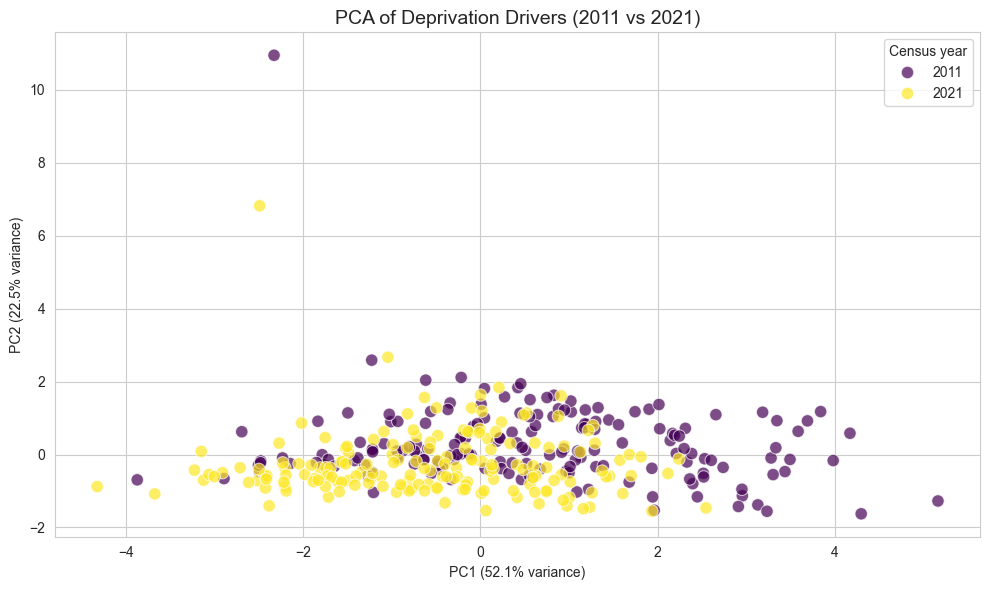

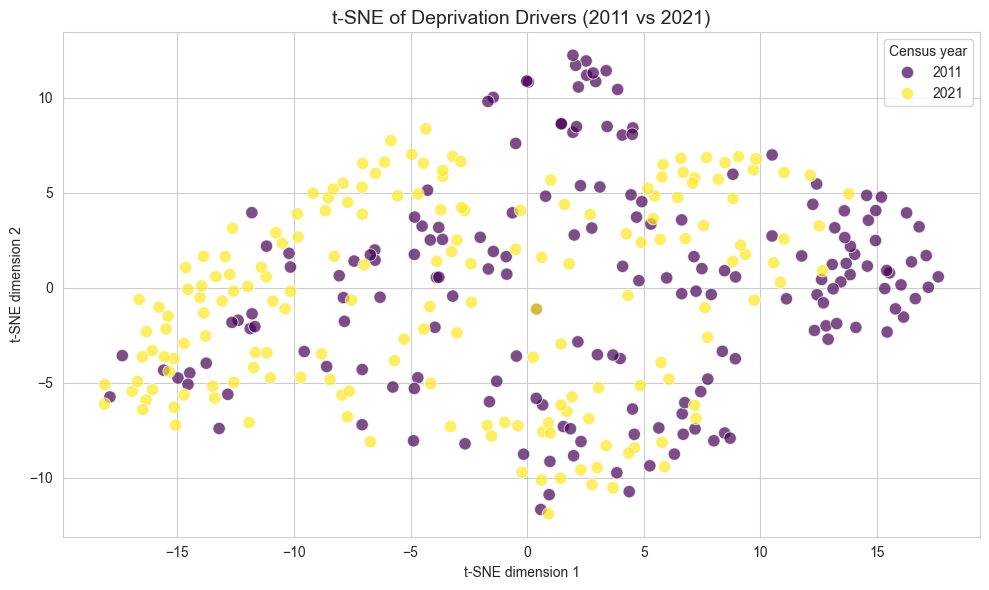

In [12]:
# 11: Visualisations
""" 
Purpose:
    - Visualise the 2021 local authorities in 2D using t-SNE, based on the
     first 3 principal components (PC1-PC3) from the PCA.
    - This reveals clustering patterns and separation of deprived vs. affluent
     areas.

Parameters used:
    - n_components=2        : reduce to 2D for plotting.
    - perplexity=40         : balances local/global structure (good for ~300 LAs).
    - max_iter=1000         : sufficient for convergence.
    - init="pca"            : start from PCA solution (faster, deterministic).
    - learning_rate="auto"  : let sklearn choose optimal learning rate.

Output:
    - Adds columns "tSNE1" and "tSNE2" to master_pca.
    - Prints the 5 most deprived (highest PC1) and 5 least deprived (lowest PC1)
     local authorities in 2021, along with their PC1 value and the direct
     deprivation percentage from the original data.
"""

master_pca_renamed = master_pca.rename(columns=RENAME_MAP)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


plt.figure(figsize=(10,6))
sns.scatterplot(data=master_pca_renamed, x="PC1", y="PC2", hue="year", alpha=0.7, palette="viridis", s=80)
plt.title("PCA of Deprivation Drivers (2011 vs 2021)", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Census year")
plt.tight_layout()
plt.savefig(OUT_PATH + "PCA_scatter.png", dpi=150)
plt.show()


plt.figure(figsize=(10,6))
sns.scatterplot(data=master_pca_renamed, x="tSNE1", y="tSNE2", hue="year", alpha=0.7, palette="viridis", s=80)
plt.title("t-SNE of Deprivation Drivers (2011 vs 2021)", fontsize=14)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(title="Census year")
plt.tight_layout()
plt.savefig(OUT_PATH + "tSNE_scatter.png", dpi=150)
plt.show()

# 12. Empirical Bayes Estimation of Deprivation Rates
### Applies an Empirical Bayes hierarchical model to estimate smoothed deprivation rates at Local Authority level, incorporating shrinkage toward the national mean and generating posterior estimates with credible intervals to stabilise small-area variability and enable robust temporal change analysis.


In [13]:
# 12: Bayesian Empirical Bayes 
def empirical_bayes(df, year):
    """
        Apply Bayesian Empirical Bayes shrinkage to deprivation rates.

        This function takes a DataFrame of local authority deprivation data for a
        single year and computes:
        - National (prior) deprivation rate.
        - Between-area variance and shrinkage factor (kappa).
        - Posterior Beta distribution parameters for each LA.
        - Posterior mean deprivation rate (shrunk estimate) and 95% credible intervals.
        - Various diagnostic metrics (shrinkage in percentage points, log10 households).

        The method uses a Beta-Binomial model with a Beta prior whose parameters are
        estimated from the marginal distribution of the observed rates (empirical Bayes).
        Shrinkage is stronger for small-population LAs.

        Args:
            df (pandas.DataFrame): Master DataFrame for a single year, containing at least:
                - "LA" (str): Local authority name.
                - "dep_Total" (numeric): Total number of households.
                - "dep_deprivation_pct" (numeric): Deprivation percentage (0-100).
            year (int): Census year (e.g., 2011 or 2021), used for printing and output.

        Returns:
            pandas.DataFrame: A DataFrame with one row per LA containing:
                - "LA", "year"
                - "total_households": Total households (int)
                - "deprived_count": Estimated number of deprived households (int)
                - "naive_rate": Raw deprivation rate (%, before shrinkage)
                - "posterior_mean": Shrunk deprivation rate (%, posterior mean)
                - "ci_lo_95", "ci_hi_95": 95% credible interval bounds (%)
                - "ci_width": Width of credible interval (percentage points)
                - "shrinkage_pp": Posterior mean - naive rate (percentage points)
                - "national_rate_pct": National deprivation rate (%)
                - "kappa": Shrinkage factor (higher = more pooling)
                - "log_households": log10(total_households) for diagnostics
    """
    total = df["dep_Total"].astype(float)
    deprived_pct = df["dep_deprivation_pct"] / 100
    deprived = (deprived_pct * total).round(0)
    not_dep_pct = total - deprived
    naive_rate = deprived / total

    p_national = deprived.sum() / total.sum()
    observed_var = naive_rate.var()
    sampling_var = (naive_rate * (1 - naive_rate) / total).mean()
    between_var = max(observed_var - sampling_var, 0.0001)
    kappa = max(p_national * (1 - p_national) / between_var - 1, 1)
    alpha_prior = p_national * kappa
    beta_prior = (1 - p_national) * kappa
    alpha_post = alpha_prior + deprived
    beta_post = beta_prior + (total - deprived)
    posterior_mean = alpha_post / (alpha_post + beta_post)
    ci_lo = stats.beta.ppf(0.025, alpha_post, beta_post)
    ci_hi = stats.beta.ppf(0.975, alpha_post, beta_post)
    print(f"  Year {year}: national={p_national:.4f}, kappa={kappa:.1f}, "
          f"Prior Beta({alpha_prior:.1f}, {beta_prior:.1f})")
    print(f"    Max |shrinkage|: {abs(posterior_mean.values - naive_rate.values).max()*100:.4f} pp")
    return pd.DataFrame({
        "LA": df["LA"].values, "year": year,
        "total_households": total.values.astype(int),
        "deprived_count": deprived.values.astype(int),
        "naive_rate": (naive_rate.values * 100).round(2),
        "posterior_mean": (posterior_mean.values * 100).round(2),
        "ci_lo_95": (ci_lo * 100).round(2),
        "ci_hi_95": (ci_hi * 100).round(2),
        "ci_width": ((ci_hi - ci_lo) * 100).round(2),
        "shrinkage_pp": ((posterior_mean.values - naive_rate.values) * 100).round(4),
        "national_rate_pct": round(p_national * 100, 2),
        "dep_deprivation_pct": df["dep_deprivation_pct"].values,
        "kappa": round(kappa, 1),
        "log_households": np.log10(total.values).round(3)})

print("Bayesian emperical bayes")
df_11 = master_pca[master_pca["year"] == 2011].reset_index(drop=True)
df_21 = master_pca[master_pca["year"] == 2021].reset_index(drop=True)

bay_11 = empirical_bayes(df_11, 2011)
bay_21 = empirical_bayes(df_21, 2021)
bayes_combined = pd.concat([bay_11, bay_21], ignore_index=True)

# Change analysis
change = bay_11[["LA","posterior_mean"]].merge(
    bay_21[["LA","posterior_mean"]], on="LA", suffixes=("_2011","_2021"))
change["change_pp"] = (change["posterior_mean_2021"] - change["posterior_mean_2011"]).round(2)
change["direction"] = change["change_pp"].apply(
    lambda x: "Meaningfully improved" if x <= -8
    else ("Marginally improved" if x < 0 else "Worsened"))

print(f"\nChange direction:\n{change['direction'].value_counts()}")
print(f"\nMost improved:")
print(change.nsmallest(5,"change_pp")[["LA","posterior_mean_2011","posterior_mean_2021","change_pp"]].to_string(index=False))
print(f"\nCI width range:")
print(f"  Smallest: {bayes_combined['ci_width'].min():.2f} pp, Largest: {bayes_combined['ci_width'].max():.2f} pp")


Bayesian emperical bayes
  Year 2011: national=0.5766, kappa=68.1, Prior Beta(39.3, 28.8)
    Max |shrinkage|: 0.2526 pp
  Year 2021: national=0.5171, kappa=103.4, Prior Beta(53.5, 49.9)
    Max |shrinkage|: 0.2424 pp

Change direction:
direction
Marginally improved      149
Meaningfully improved     26
Name: count, dtype: int64

Most improved:
            LA  posterior_mean_2011  posterior_mean_2021  change_pp
City of London                55.05                40.47     -14.58
        Newham                75.01                60.69     -14.32
 Tower Hamlets                67.26                53.60     -13.66
       Hackney                68.53                55.05     -13.48
     Southwark                63.80                51.45     -12.35

CI width range:
  Smallest: 0.24 pp, Largest: 6.06 pp


# 13. Prepare Dataset for Machine Learning Models
### Prepares machine learning dataset by merging 2011 features with 2021 deprivation outcomes at Local Authority level, standardising predictor variables to enable supervised learning of deprivation change patterns.

In [14]:
# 13: Prepare ML data
""" 
Purpose:
    - Create a supervised learning dataset to predict 2021 deprivation rates
     using 2011 indicators (including 2011 deprivation itself).
    - Merge 2011 and 2021 DataFrames on LA to align features (2011) with target (2021).
    - Define feature columns: health, unemployment, qualifications, central heating,
     large bedrooms, and baseline deprivation in 2011.
    - Standardise all features using StandardScaler.

Output variables:
    - X_raw : raw feature matrix (n LAs x 6 features)
    - X_std : standardised feature matrix (mean=0, std=1)
    - y : target vector (2021 deprivation percentage)
    - scaler_ml : fitted StandardScaler for later use (e.g., prediction on new data)
    - ml_data : merged DataFrame for reference (includes LA and both deprivations)

Summary statistics printed:
    - Number of LAs and features
    - Min, max, mean of target variable (2021 deprivation)
"""
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.dummy import DummyRegressor

df_11_ml = master_pca[master_pca["year"] == 2011].reset_index(drop=True)
df_21_ml = master_pca[master_pca["year"] == 2021].reset_index(drop=True)

ml_data = df_11_ml.merge(df_21_ml[["LA","dep_deprivation_pct"]],
                         on="LA", suffixes=("_2011","_2021"))

feature_cols_ml = [
    "hlt_Poor health_pct",
    "eco_Economically active: Unemployed_pct",
    "qua_No qualifications_pct",
    "ctlheat_No central heating_pct",
    "bdrms_4 or more bedrooms_pct",
    "dep_deprivation_pct_2011"]

X_raw = ml_data[feature_cols_ml].values
y = ml_data["dep_deprivation_pct_2021"].values
n = len(y)

scaler_ml = StandardScaler()
X_std = scaler_ml.fit_transform(X_raw)

print(f"ML dataset: {n} LAs, {len(feature_cols_ml)} features")
print(f"Target (2021 dep score): min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")


ML dataset: 175 LAs, 6 features
Target (2021 dep score): min=38.53, max=62.41, mean=52.38


# 14. Bayesian Modelling of Deprivation Change
### Models change in deprivation between 2011 and 2021 using a Bayesian linear regression framework with standardised predictors, estimating posterior effects and uncertainty, and validating predictive performance via leave-one-out cross-validation.

In [15]:
# 14: Predict change in deprivation (additional analysis)
""" 
 Purpose:
    - Model the 2011-2021 change in deprivation (percentage points) using 2011 driver variables (health, unemployment, no qualifications, 
no central heating, 4+ bedrooms).
    - Uses a Bayesian linear regression with conjugate priors:
    - Prior on coefficients: zero-mean Gaussian with precision tau2 = 10(weakly informative).
    - Prior on noise variance: Inverse-Gamma(a0=1, b0=1) (weak).
    - Computes posterior means, standard deviations, and 95% credible intervals for each coefficient.
    - Performs leave-one-out cross-validation (LOO-CV) to evaluate predictive performance (R2).

Workflow:
    1. Compute deprivation change (2021 - 2011) as target variable.
    2. Standardise the 5 feature columns.
    3. Add an intercept column to the design matrix.
    4. Fit Bayesian model using closed-form updates (conjugate Normal-InvGamma).
    5. Print coefficient estimates, uncertainty, and significance (95% CI excludes 0).
    6. Perform LOO-CV and report R².

Output printed:
    - For each predictor: estimate, std error, 95% CI, and significance flag.
    - LOO-CV R² for the change model.
"""


ml_data["dep_change"] = ml_data["dep_deprivation_pct_2021"] - ml_data["dep_deprivation_pct_2011"]
feature_cols_change = [
    "hlt_Poor health_pct",
    "eco_Economically active: Unemployed_pct",
    "qua_No qualifications_pct",
    "ctlheat_No central heating_pct",
    "bdrms_4 or more bedrooms_pct"]
X_change = ml_data[feature_cols_change].values
y_change = ml_data["dep_change"].values

scaler_change = StandardScaler()
X_change_std = scaler_change.fit_transform(X_change)
n_change = len(y_change)
X_design_change = np.column_stack([np.ones(n_change), X_change_std])

tau2 = 10.0; a0 = 1.0; b0 = 1.0
Lambda_prior = np.eye(X_design_change.shape[1]) / tau2
Lambda_post_change = Lambda_prior + X_design_change.T @ X_design_change
Lambda_post_inv_change = np.linalg.inv(Lambda_post_change)
mu_post_change = Lambda_post_inv_change @ (X_design_change.T @ y_change)
residuals_change = y_change - X_design_change @ mu_post_change
a_post_change = a0 + n_change/2
b_post_change = b0 + 0.5 * (residuals_change @ residuals_change)
sigma2_post_change = b_post_change / (a_post_change - 1)
beta_std_change = np.sqrt(np.diag(Lambda_post_inv_change) * sigma2_post_change)
beta_ci_lo_change = mu_post_change - 1.96 * beta_std_change
beta_ci_hi_change = mu_post_change + 1.96 * beta_std_change

print("Bayesian model for change in deprivation(pp)")

names_change = ["Intercept"] + feature_cols_change
for i, name in enumerate(names_change):
    sig = "Yes" if (beta_ci_lo_change[i] > 0 or beta_ci_hi_change[i] < 0) else "No"
    print(f"  {name:45} {mu_post_change[i]:8.3f} {beta_std_change[i]:8.3f} "
          f"[{beta_ci_lo_change[i]:7.3f}, {beta_ci_hi_change[i]:7.3f}] {sig:>5}")

# LOO-CV for change model
y_pred_change_cv = np.zeros(n_change)
for i in range(n_change):
    mask = np.ones(n_change, dtype=bool); mask[i] = False
    X_tr = X_design_change[mask]; y_tr = y_change[mask]
    x_te = X_design_change[i]
    Lam = Lambda_prior + X_tr.T @ X_tr
    Lam_inv = np.linalg.inv(Lam)
    mu = Lam_inv @ (X_tr.T @ y_tr)
    a_cv = a0 + (n_change-1)/2
    res_cv = y_tr - X_tr @ mu
    b_cv = b0 + 0.5 * (res_cv @ res_cv)
    s2_cv = b_cv / (a_cv - 1)
    y_pred_change_cv[i] = x_te @ mu
print(f"\nLOO-CV for deprivation: R2 = {r2_score(y_change, y_pred_change_cv):.3f}")


Bayesian model for change in deprivation(pp)
  Intercept                                       -6.363    0.103 [ -6.565,  -6.160]   Yes
  hlt_Poor health_pct                             -0.965    0.200 [ -1.356,  -0.574]   Yes
  eco_Economically active: Unemployed_pct         -0.779    0.170 [ -1.111,  -0.446]   Yes
  qua_No qualifications_pct                        1.464    0.191 [  1.089,   1.838]   Yes
  ctlheat_No central heating_pct                  -0.622    0.111 [ -0.840,  -0.404]   Yes
  bdrms_4 or more bedrooms_pct                     0.814    0.166 [  0.489,   1.140]   Yes

LOO-CV for deprivation: R2 = 0.567


# 15. Bayesian Linear Regression on 2021 Deprivation
### Fits a Bayesian linear regression model to estimate posterior effects of deprivation drivers on 2021 deprivation levels, providing coefficient uncertainty via credible intervals and quantifying overall model residual variance.

In [16]:
# 15: Bayesian Linear 
"""  
Purpose:
    - Fit a Bayesian linear regression to predict 2021 deprivation from
    2011 features + 2011 deprivation (6 predictors + intercept).
    Uses conjugate Normal-InvGamma priors:
    Coefficients ~ N(0, 1/tau2) with tau2 = 10 (weakly informative)
    Noise variance σ² ~ Inv-Gamma(a0=1, b0=1) (weak, improper limit)
    - Computes posterior mean, standard deviation, and 95% credible intervals
    for each coefficient.
    - Prints posterior summary (coefficient estimate, std, CI, significance)
    and posterior residual standard deviation (sigma).

Output printed:
    - Table of coefficients with significance (CI excludes 0).
    - Posterior sigma (residual standard deviation).
"""
X_design = np.column_stack([np.ones(n), X_std])
p = X_design.shape[1]
Lambda_prior = np.eye(p) / tau2
Lambda_post = Lambda_prior + X_design.T @ X_design
Lambda_post_inv = np.linalg.inv(Lambda_post)
mu_post = Lambda_post_inv @ (X_design.T @ y)
a_post = a0 + n / 2
residuals_bayes = y - X_design @ mu_post
b_post = b0 + 0.5 * (residuals_bayes @ residuals_bayes)
sigma2_post = b_post / (a_post - 1)
beta_std = np.sqrt(np.diag(Lambda_post_inv) * sigma2_post)
beta_ci_lo = mu_post - 1.96 * beta_std
beta_ci_hi = mu_post + 1.96 * beta_std

print("Bayesian positerior coefficients")
names = ["Intercept"] + feature_cols_ml
for i, name in enumerate(names):
    sig = "Yes" if (beta_ci_lo[i] > 0 or beta_ci_hi[i] < 0) else "No"
    print(f"  {name:45} {mu_post[i]:8.3f} {beta_std[i]:8.3f} "
          f"[{beta_ci_lo[i]:7.3f}, {beta_ci_hi[i]:7.3f}] {sig:>5}")
print(f"\nPosterior sigma (residual std): {np.sqrt(sigma2_post):.3f}")


Bayesian positerior coefficients
  Intercept                                       52.349    0.092 [ 52.168,  52.529]   Yes
  hlt_Poor health_pct                             -0.441    0.193 [ -0.820,  -0.062]   Yes
  eco_Economically active: Unemployed_pct         -0.064    0.183 [ -0.424,   0.295]    No
  qua_No qualifications_pct                        1.595    0.171 [  1.259,   1.930]   Yes
  ctlheat_No central heating_pct                  -0.231    0.114 [ -0.455,  -0.008]   Yes
  bdrms_4 or more bedrooms_pct                     0.332    0.164 [  0.011,   0.653]   Yes
  dep_deprivation_pct_2011                         4.238    0.247 [  3.754,   4.721]   Yes

Posterior sigma (residual std): 1.219


# 16. Leave-One-Out Cross-Validation (Bayesian Model)
### Performs leave-one-out cross-validation for the Bayesian linear regression model to evaluate predictive accuracy and calibration, reporting R2, MAE, RMSE, and 95% credible interval coverage against the target confidence level.


In [17]:
# 16: LOO-CV for Bayesian model
"""  
Purpose:
    - Evaluate predictive performance of the Bayesian model using
      leave-one-out cross-validation.
    - For each held-out LA, refit the model on the remaining n-1 observations
     and predict the 2021 deprivation.
    - Also compute 95% predictive intervals for each left-out point.
    - Report:
    * R² (coefficient of determination)
    * MAE (mean absolute error)
    * RMSE (root mean squared error)
    * Coverage of 95% predictive intervals (should be ≈95% if model is
    well-calibrated).

Output printed:
    - LOO-CV performance metrics.
"""

y_pred_bayes_cv = np.zeros(n)
y_pred_ci_lo_cv = np.zeros(n)
y_pred_ci_hi_cv = np.zeros(n)


for i in range(n):
    mask = np.ones(n, dtype=bool); mask[i] = False
    X_tr, y_tr = X_design[mask], y[mask]
    x_te = X_design[i]
    Lam = Lambda_prior + X_tr.T @ X_tr
    Lam_inv = np.linalg.inv(Lam)
    mu = Lam_inv @ (X_tr.T @ y_tr)
    a_cv = a0 + (n-1)/2
    res_cv = y_tr - X_tr @ mu
    b_cv = b0 + 0.5 * (res_cv @ res_cv)
    s2_cv = b_cv / (a_cv - 1)
    y_pred_bayes_cv[i] = x_te @ mu
    pv = s2_cv * (1 + x_te @ Lam_inv @ x_te)
    y_pred_ci_lo_cv[i] = y_pred_bayes_cv[i] - 1.96 * np.sqrt(pv)
    y_pred_ci_hi_cv[i] = y_pred_bayes_cv[i] + 1.96 * np.sqrt(pv)

coverage = np.mean((y >= y_pred_ci_lo_cv) & (y <= y_pred_ci_hi_cv))
print("Bayesian LOO-CV performance:")
print(f"  R2  = {r2_score(y, y_pred_bayes_cv):.3f}")
print(f"  MAE = {mean_absolute_error(y, y_pred_bayes_cv):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y, y_pred_bayes_cv)):.3f}")
print(f"  95% CI coverage: {coverage*100:.1f}% (target: 95%)")


Bayesian LOO-CV performance:
  R2  = 0.928
  MAE = 1.011
  RMSE = 1.308
  95% CI coverage: 94.9% (target: 95%)


# 17. Baseline and Random Forest Model Comparison
### Evaluates model performance using 5-fold cross-validation by comparing a baseline mean predictor, Bayesian linear regression, and Random Forest regression, and reports standard regression metrics (R2, MAE, RMSE) alongside feature importance from the trained Random Forest model.

In [18]:
# 17: Random Forest baseline + Model comparison
"""
Purpose:
    - Compare Bayesian linear regression against:
    1. Baseline: always predict mean (DummyRegressor)
    2. Random Forest (non-linear, tree-based ensemble)
    - Random Forest uses 200 trees, max depth = 8, 5-fold CV for prediction.
    - Extract feature importances from the final RF model.

Output printed:
    - Performance table (R2, MAE, RMSE) for all three models.
    - RF feature importances (sorted).
"""

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
y_pred_rf = cross_val_predict(rf, X_raw, y, cv=kf)

baseline = DummyRegressor(strategy="mean")
y_pred_base = cross_val_predict(baseline, X_raw, y, cv=kf)

print("Model comparison")
for name, pred, has_ci in [
    ("Baseline (Mean)", y_pred_base, "No"),
    ("Bayesian Linear Regression", y_pred_bayes_cv, "Yes"),
    ("Random Forest", y_pred_rf, "No")]:
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    print(f"  {name:30} {r2:8.3f} {mae:8.3f} {rmse:8.3f} {has_ci:>8}")

rf.fit(X_raw, y)
importance = pd.DataFrame({
    "Feature": feature_cols_ml,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)
print(f"\nRF Feature importances:\n{importance.to_string(index=False)}")


Model comparison
  Baseline (Mean)                  -0.013    3.934    4.913       No
  Bayesian Linear Regression        0.928    1.011    1.308      Yes
  Random Forest                     0.881    1.221    1.681       No

RF Feature importances:
                                Feature  Importance
               dep_deprivation_pct_2011    0.829030
                    hlt_Poor health_pct    0.073830
              qua_No qualifications_pct    0.071648
           bdrms_4 or more bedrooms_pct    0.011755
         ctlheat_No central heating_pct    0.007011
eco_Economically active: Unemployed_pct    0.006726


# 18. Prediction Analysis and Statistical Outlier Detection
### Compiles Bayesian and Random Forest predictions into a unified results table, identifies statistically significant deviations using credible intervals, classifies Local Authorities by model performance, and exports key outputs including predictions, coefficients, and feature importance for further analysis and reporting.


In [19]:
# 18: Prediction results with statistical outlier detection
"""
Purpose:
    - Create a results DataFrame with actual 2021 deprivation, Bayesian predictions (with CIs), and Random Forest predictions.
    - Flag LAs whose observed 2021 score falls outside the 95% predictive interval of the Bayesian model (statistically significant deviation).
    - Categorise performance as:
    * "More deprived than predicted (significant)"
    * "Less deprived than predicted (significant)"
    * "As predicted (within CI)"
    - Save results to Excel:
    * ML Predictions.xlsx
    * bayesian_coefficients.xlsx
    * Importance.xlsx (RF feature importances)

    Output printed:
    - Count of LAs in each performance category.
"""
ml_results = pd.DataFrame({
    "LA": ml_data["LA"].values,
    "dep_score_2011": ml_data["dep_deprivation_pct_2011"].values,
    "dep_score_2021": y,
    "bayes_predicted": y_pred_bayes_cv.round(3),
    "bayes_ci_lo": y_pred_ci_lo_cv.round(3),
    "bayes_ci_hi": y_pred_ci_hi_cv.round(3),
    "bayes_ci_width": (y_pred_ci_hi_cv - y_pred_ci_lo_cv).round(3),
    "bayes_residual": (y - y_pred_bayes_cv).round(3),
    "rf_predicted": y_pred_rf.round(3),
    "rf_residual": (y - y_pred_rf).round(3)})

ml_results["outside_ci"] = (ml_results["dep_score_2021"] < ml_results["bayes_ci_lo"]) | \
                           (ml_results["dep_score_2021"] > ml_results["bayes_ci_hi"])
ml_results["performance"] = ml_results.apply(
    lambda row: "More deprived than predicted (significant)" 
                if row["dep_score_2021"] > row["bayes_ci_hi"] 
                else ("Less deprived than predicted (significant)" 
                      if row["dep_score_2021"] < row["bayes_ci_lo"]
                      else "As predicted (within CI)"),axis=1)

print("Performance breakdown (statistically significant deviations):")
print(ml_results["performance"].value_counts())
ml_results.to_excel(OUT_PATH + "ML Predictions.xlsx", index=False)

coef_table = pd.DataFrame({
    "Feature": names,
    "Posterior_Mean": mu_post.round(4),
    "Posterior_Std": beta_std.round(4),
    "CI_Lo_95": beta_ci_lo.round(4),
    "CI_Hi_95": beta_ci_hi.round(4),
    "Significant": ["Yes" if (lo > 0 or hi < 0) else "No" 
                    for lo, hi in zip(beta_ci_lo, beta_ci_hi)]})
coef_table.to_excel(OUT_PATH + "bayesian_coefficients.xlsx", index=False)
importance.to_excel(OUT_PATH + "Importance.xlsx", index=False)


Performance breakdown (statistically significant deviations):
performance
As predicted (within CI)                      166
Less deprived than predicted (significant)      8
More deprived than predicted (significant)      1
Name: count, dtype: int64


# 19. Export of Analysis Outputs for Tableau Visualisation
### Prepares and exports a suite of Tableau-ready datasets by merging PCA results, Bayesian estimates, temporal change analysis, and loadings into structured Excel files for interactive visualisation and reporting

In [20]:
# 19: Output Tableau-ready files
""" 
# Purpose:
    - Merge all derived results into a single master DataFrame for Tableau.
    - Rename columns to be human-readable.
    - Add Bayesian posterior estimates, shrinkage metrics, and change analysis.
    - Save multiple Excel files for different visualisations:
    * Main.xlsx         - full data for Tableau (LA, year, PCA scores, etc.)
    * Bayesian.xlsx     - raw vs. shrunk rates with credible intervals
    * Loadings.xlsx     - PCA component loadings (renamed features)
    * bayesian_change.xlsx - 2011-2021 change posterior means
    * master_combined_pca.xlsx - all PCA + t-SNE scores
    * plus those from Section 18.

Output printed:
    - Shapes of each saved file.
"""
tableau = master_pca_renamed.copy()
bay_rename = {
    "posterior_mean": "Posterior Mean %",
    "ci_lo_95": "CI Lower 95%",
    "ci_hi_95": "CI Upper 95%",
    "ci_width": "CI Width",
    "naive_rate": "Naive Rate %",
    "shrinkage_pp": "Shrinkage (pp)",
    "national_rate_pct": "National Rate %",
    "log_households": "Log Households",
    "kappa": "Kappa"}
bay_merge = bayes_combined.rename(columns=bay_rename)[["LA","year"] + list(bay_rename.values())]
tableau = tableau.merge(bay_merge, on=["LA","year"], how="left")
change_rename = {"change_pp": "Change (pp)", "direction": "Direction"}
change_renamed = change.rename(columns=change_rename)
tableau = tableau.merge(change_renamed[["LA","Change (pp)","Direction"]], on="LA", how="left")

bayes_chart = bayes_combined.sort_values(["year","posterior_mean"], ascending=[True,True])
bayes_chart["rank_within_year"] = bayes_chart.groupby("year").cumcount() + 1
bayes_chart = bayes_chart.rename(columns=bay_rename)

loadings_out = loadings.reset_index().rename(columns={"index": "Feature"})
loadings_out["Feature"] = loadings_out["Feature"].replace({
    "hlt_Poor health_pct": "Poor Health %",
    "eco_Economically active: Unemployed_pct": "Unemployed %",
    "qua_No qualifications_pct": "No Qualifications %",
    "ctlheat_No central heating_pct": "No Central Heating %",
    "bdrms_4 or more bedrooms_pct": "4+ Bedrooms %"})

tableau.to_excel(OUT_PATH + "Main.xlsx", index=False)
bayes_chart.to_excel(OUT_PATH + "Bayesian.xlsx", index=False)
loadings_out.to_excel(OUT_PATH + "Loadings.xlsx", index=False)
change.to_excel(OUT_PATH + "bayesian_change.xlsx", index=False)
master_pca.to_excel(OUT_PATH + "master_combined_pca.xlsx", index=False)

print("All files saved")
print(f"  Main.xlsx: {tableau.shape}")
print(f"  Bayesian.xlsx: {bayes_chart.shape}")
print(f"  Loadings.xlsx: {loadings_out.shape}")
print(f"  bayesian_change.xlsx: {change.shape}")
print(f"  master_combined_pca.xlsx: {master_pca.shape}")
print(f"  ML Predictions.xlsx: {ml_results.shape}")
print(f"  bayesian_coefficients.xlsx: {coef_table.shape}")
print(f"  Importance.xlsx: {importance.shape}")


All files saved
  Main.xlsx: (350, 32)
  Bayesian.xlsx: (350, 15)
  Loadings.xlsx: (5, 6)
  bayesian_change.xlsx: (175, 5)
  master_combined_pca.xlsx: (350, 21)
  ML Predictions.xlsx: (175, 12)
  bayesian_coefficients.xlsx: (7, 6)
  Importance.xlsx: (6, 2)
